# FunSearch for CVRP: Sample-Efficient Heuristic Discovery

**Authors:** LAI Yikai, QIN Ziheng, QIN Yuancheng

## Abstract

This notebook demonstrates how to use **FunSearch** -- an evolutionary program-synthesis method that uses a Large Language Model (LLM) as a mutation operator -- to automatically discover construction heuristics for the **Capacitated Vehicle Routing Problem (CVRP)**.

### What is CVRP?
Given a depot and a set of customers with demands, find the minimum-cost set of routes (starting and ending at the depot) such that:
- Every customer is visited exactly once
- The total demand on each route does not exceed vehicle capacity

### What is FunSearch?
FunSearch treats program synthesis as an evolutionary algorithm. We evolve a `priority()` function that guides a greedy route builder. The LLM proposes mutations to this function, and an island-based population maintains diversity.

### Key Contributions of this Work
1. **Complete FunSearch pipeline** for CVRP with island-based evolution, behavioral clustering, and observability
2. **Train/test/validation splits** to measure generalization -- LLM-generated heuristics can overfit to training instance structure
3. **Controlled comparison** of two algorithmic skeletons: greedy priority vs. Clarke-Wright savings
4. **Dynamic generalization penalty** that adjusts based on train-validation gap

### Key Findings (from our experiments)
1. **The algorithmic skeleton dominates LLM capability**: a savings spec achieves 1.68% gap while a priority spec plateaus at 11.65% with the same 7B model
2. **Frontier models find good solutions quickly** (best at iteration 61) but cannot escape local optima
3. **Dynamic generalization penalties prevent overfitting** but may be too aggressive, capping exploration
4. **LLM-driven search is most effective when the initial heuristic is competent but suboptimal**

### Notebook Structure
| Section | Content | Runnable? |
|---|---|---|
| 1. Setup | Install packages, import modules | Yes |
| 2. Data Loading | Download CVRPLib A-set instances | Yes |
| 3. Baseline Evaluation | Run NN, CW, CW+2-opt heuristics | Yes |
| 4. FunSearch Demo | Evolution loop (Mock or Real LLM) | Yes |
| 5. Real Experiments | Download pre-computed experiment outputs from GitHub release | Yes |
| 6. Report Reproduction | Reproduce all tables and figures from the paper | Yes |
| 7. Program Inspection | Extract and display best evolved programs | Yes |
| 8. Real LLM (Optional) | Instructions for running with a real LLM API | Optional |

**Full codebase:** https://github.com/laiyk5/funsearch_cvrp

## 1. Environment Setup

Install the `funsearch-cvrp` package directly from GitHub. In Google Colab, prefix shell commands with `!`. If running locally inside a cloned repo, use `pip install -e "."` instead.

We also install `matplotlib`, `numpy`, `scipy`, and `pandas` for visualization and analysis.

In [1]:
# Detect whether we are running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Install the funsearch-cvrp package from GitHub.
    # This pulls the latest version of the source code and makes all modules importable.
    !pip install -q git+https://github.com/laiyk5/funsearch_cvrp.git
    # Visualization and data-analysis dependencies used throughout this notebook.
    !pip install -q matplotlib numpy scipy pandas py7zr
    print("Installed dependencies for Colab.")
else:
    print("Not in Colab. Skipping pip install. Ensure dependencies are available locally.")


Not in Colab. Skipping pip install. Ensure dependencies are available locally.


In [2]:
# =============================================================================
# Standard imports used throughout the notebook
# =============================================================================
import os
import sys
import json
import math
import time
import random
import zipfile
import urllib.request
from pathlib import Path
from dataclasses import dataclass
from typing import Callable, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# FunSearch CVRP domain modules
from funsearch_cvrp.cvrp.io import load_cvrplib_folder
from funsearch_cvrp.cvrp.core import (
    CVRPInstance, Solution, solution_distance,
    is_valid_solution, gap_score, make_greedy_solver
)
from funsearch_cvrp.cvrp.baselines import (
    nearest_neighbor_heuristic,
    clarke_wright_savings_heuristic,
    with_two_opt,
)

# FunSearch engine modules
from funsearch_cvrp.funsearch.code_manipulation import text_to_program, text_to_function
from funsearch_cvrp.funsearch.config import ProgramsDatabaseConfig
from funsearch_cvrp.funsearch.programs_database import ProgramsDatabase
from funsearch_cvrp.funsearch.evaluator import Evaluator, SimpleSandbox
from funsearch_cvrp.funsearch.sampler import LLM, Sampler

print("All imports successful.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All imports successful.
NumPy version: 2.4.4
Pandas version: 3.0.2


## 2. Data Loading

We use the **CVRPLib A-set** (27 instances, 32-80 customers) as our benchmark. Each instance has a known optimal or best-known solution published in the CVRPLib repository.

If the data directory does not exist locally, we download the pre-packaged archive from the project's GitHub release.

In [3]:
# =============================================================================
# Locate or download CVRPLib A-set instances
# =============================================================================
import py7zr

# Detect whether we are running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Optional: mount Google Drive to persist data and outputs
    # from google.colab import drive
    # drive.mount("/content/drive")
    pass

# In Colab (or when data is missing locally) use a path relative to the
# working directory.  When running locally inside the repo the notebook
# lives in notebooks/ so we go up one level.
if IN_COLAB:
    DATA_DIR = Path("data/cvrplib/A")
else:
    DATA_DIR = Path("../data/cvrplib/A")

if not DATA_DIR.exists():
    # Running in Colab or without local data -- download from GitHub release
    print("Local data not found. Downloading dataset archive from GitHub release...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    archive_path = DATA_DIR.parent / (DATA_DIR.name + ".7z")
    if not archive_path.exists():
        url = "https://github.com/laiyk5/funsearch_cvrp/releases/download/v1.0.0/A.7z"
        print(f"  Downloading {url} ...")
        urllib.request.urlretrieve(url, archive_path)
    print(f"  Extracting {archive_path} ...")
    with py7zr.SevenZipFile(archive_path, mode='r') as z:
        z.extractall(path=DATA_DIR.parent)
    print(f"Download complete. Data directory: {DATA_DIR.absolute()}")
else:
    print(f"Using local data: {DATA_DIR.absolute()}")

# Load all instances with their optimal solutions
instances_data = load_cvrplib_folder(DATA_DIR)
print(f"\nLoaded {len(instances_data)} instances")
for inst, sol, opt in instances_data[:3]:
    print(f"  {inst.name}: {inst.n_customers} customers, capacity={inst.capacity}, optimal={opt}")


Using local data: /Users/laiyk/Dev/Funsearch-CVRP/notebooks/../data/cvrplib/A

Loaded 27 instances
  A-n32-k5: 31 customers, capacity=100, optimal=784.0
  A-n33-k5: 32 customers, capacity=100, optimal=661.0
  A-n33-k6: 32 customers, capacity=100, optimal=742.0


In [4]:
# =============================================================================
# Split into train / validation / test sets
# =============================================================================
# We hold out 15% for validation and 20% for test to measure generalization.
# The split is deterministic (seed=42) so it is reproducible across runs.
random.seed(42)
indices = list(range(len(instances_data)))
random.shuffle(indices)

n_val = max(1, int(len(indices) * 0.15))
n_test = max(1, int(len(indices) * 0.20))

val_indices = indices[:n_val]
test_indices = indices[n_val:n_val + n_test]
train_indices = indices[n_val + n_test:]

train_data = [instances_data[i] for i in train_indices]
val_data = [instances_data[i] for i in val_indices]
test_data = [instances_data[i] for i in test_indices]

print(f"Train:      {len(train_data)} instances")
print(f"Validation: {len(val_data)} instances")
print(f"Test:       {len(test_data)} instances")

Train:      18 instances
Validation: 4 instances
Test:       5 instances


## 3. Baseline Evaluation

Before running FunSearch, we establish baseline performance using three classical hand-designed heuristics:

1. **Nearest Neighbor (NN)** -- greedily visit the closest feasible customer at each step
2. **Clarke-Wright Savings (CW)** -- iteratively merge routes based on distance savings
3. **CW + 2-opt** -- apply 2-opt local search to improve CW routes

We report the **gap** above optimal: gap = (distance - optimal) / optimal.

These baselines appear in Table 1 of the report.

In [5]:
# =============================================================================
# Evaluation utilities
# =============================================================================
def evaluate_on_split(data, solver_fn):
    # Evaluate a solver on a data split.
    # Returns a list of result dicts with keys: instance, valid, distance, optimal, gap, n_routes.
    results = []
    for inst, _, opt in data:
        routes = solver_fn(inst)
        valid, reason = is_valid_solution(inst, routes)
        dist = solution_distance(inst, routes)
        gap = gap_score(dist, opt) if opt > 0 else 0.0
        results.append({
            "instance": inst.name,
            "valid": valid,
            "distance": dist,
            "optimal": opt,
            "gap": gap,
            "n_routes": len(routes),
        })
    return results


def summarize(results):
    # Compute mean, median, and max gap; also count valid solutions.
    gaps = [r["gap"] for r in results if r["valid"]]
    return {
        "mean_gap": float(np.mean(gaps)) if gaps else float("inf"),
        "median_gap": float(np.median(gaps)) if gaps else float("inf"),
        "max_gap": float(np.max(gaps)) if gaps else float("inf"),
        "valid_count": sum(1 for r in results if r["valid"]),
        "total": len(results),
    }


# =============================================================================
# Run all baselines on the training set
# =============================================================================
baselines = {
    "Nearest Neighbor": nearest_neighbor_heuristic,
    "Clarke-Wright Savings": clarke_wright_savings_heuristic,
    "CW + 2-opt": with_two_opt(clarke_wright_savings_heuristic),
}

baseline_results = {}
for name, solver in baselines.items():
    results = evaluate_on_split(train_data, solver)
    baseline_results[name] = results
    summary = summarize(results)
    print(f"{name:30s}  mean_gap={summary['mean_gap']:.2%}  valid={summary['valid_count']}/{summary['total']}")

Nearest Neighbor                mean_gap=40.58%  valid=18/18
Clarke-Wright Savings           mean_gap=5.06%  valid=18/18
CW + 2-opt                      mean_gap=4.78%  valid=18/18


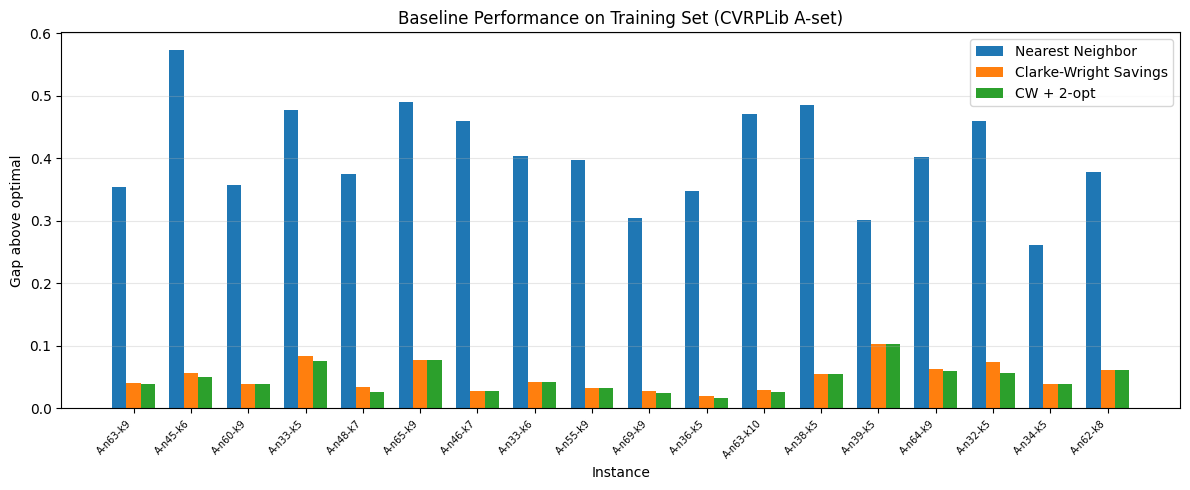

In [6]:
# =============================================================================
# Visualize baseline gaps per instance (training set)
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(train_data))
width = 0.25
instance_names = [inst.name for inst, _, _ in train_data]

for i, (name, results) in enumerate(baseline_results.items()):
    gaps = [r["gap"] for r in results]
    ax.bar(x + i * width, gaps, width, label=name)

ax.set_xlabel("Instance")
ax.set_ylabel("Gap above optimal")
ax.set_title("Baseline Performance on Training Set (CVRPLib A-set)")
ax.set_xticks(x + width)
ax.set_xticklabels(instance_names, rotation=45, ha="right", fontsize=7)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. FunSearch Demo

This section demonstrates the full FunSearch loop. You can run it with either a **Mock LLM** (default, no API key needed) or a **Real LLM** (requires API credentials).

### How it works
1. We define a `priority()` function template that the greedy solver calls at every decision point
2. We create an island-based `ProgramsDatabase` that maintains a population of evolved programs
3. The `Evaluator` runs each proposed program on all training instances and returns a score
4. The LLM proposes mutations (variations of the priority function)
5. Accepted programs are registered into the database; rejected ones are discarded

Set `USE_MOCK_LLM = False` in the cell below to switch to a real LLM. The real experiments (Sections 5-7) use pre-computed outputs downloaded from GitHub.

In [7]:
# =============================================================================
# 4.0 Choose your LLM backend
# =============================================================================
USE_MOCK_LLM = True  # Set to False to use a real LLM API

# Real LLM settings (only used if USE_MOCK_LLM = False)
REAL_LLM_MODEL = "deepseek-v4-flash"  # e.g. "gpt-4", "qwen2.5-coder-7b"
REAL_LLM_BASE_URL = "https://api.openai.com/v1"
REAL_LLM_API_KEY = ""  # Leave empty to use OPENAI_API_KEY env var

if not USE_MOCK_LLM and not REAL_LLM_API_KEY:
    import os
    REAL_LLM_API_KEY = os.environ.get("OPENAI_API_KEY", "")

print(f"LLM mode: {'MOCK (no API calls)' if USE_MOCK_LLM else 'REAL'}")
if not USE_MOCK_LLM:
    print(f"  Model: {REAL_LLM_MODEL}")
    print(f"  Base URL: {REAL_LLM_BASE_URL}")
    print(f"  API Key: {'set' if REAL_LLM_API_KEY else 'NOT SET - will fail!'}")

LLM mode: MOCK (no API calls)


In [8]:
# =============================================================================
# 4.1 Define the evaluation harness
# =============================================================================
# The specification code is the template that FunSearch mutates.
# The function signature is fixed; only the body is evolved.
SPEC_CODE = '''
def priority(
  current_node: int,
  candidate: int,
  instance,
  remaining_capacity: int,
  route: list,
  route_demand: int,
  unserved: set,
) -> float:
  """Score a candidate customer for the greedy route builder."""
  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur
'''

template = text_to_program(SPEC_CODE)
function_to_evolve = "priority"

# Training inputs: (instance, optimal_distance) pairs
train_inputs = [(inst, opt) for inst, _, opt in train_data]


def evaluate_cvrp(test_input, priority_fn):
    # Evaluate a priority function on a single CVRP instance.
    # Returns negative gap (higher is better). Invalid solutions get -1e9.
    instance, optimal = test_input
    solver = make_greedy_solver(priority_fn)
    routes = solver(instance)
    valid, reason = is_valid_solution(instance, routes)
    if not valid:
        return -1e9
    dist = solution_distance(instance, routes)
    gap = gap_score(dist, optimal)
    return -gap  # FunSearch maximizes, so negate the gap

In [9]:
# =============================================================================
# 4.2 Configure the Programs Database
# =============================================================================
import logging
# Keep notebook output clean during initialisation
logging.getLogger("funsearch").setLevel(logging.ERROR)

db_config = ProgramsDatabaseConfig(
    num_islands=10,                          # 10 evolutionary islands
    reset_period=600,                        # Reset weakest islands every 10 minutes
    functions_per_prompt=3,                  # Number of prior versions in each LLM prompt
    cluster_sampling_temperature_init=0.1,
    cluster_sampling_temperature_period=1000,
    score_bucket_precision=None,             # Exact signature matching
    score_reduction_method="percentile_25",  # Use 25th percentile across instances
    generalization_penalty=0.05,             # Small CV penalty to discourage overfitting
)

database = ProgramsDatabase(
    config=db_config,
    template=template,
    function_to_evolve=function_to_evolve,
)

evaluator = Evaluator(
    database=database,
    template=template,
    function_to_evolve=function_to_evolve,
    evaluate_fn=evaluate_cvrp,
    inputs=train_inputs,
    timeout_seconds=30,
    sandbox=SimpleSandbox(),
)

# Seed every island with the template function so populations are not empty.
initial_body = template.get_function(function_to_evolve).body
evaluator.analyse(initial_body, island_id=None, version_generated=None)

print("Database and evaluator initialized.")
print(f"  Islands: {db_config.num_islands}")
print(f"  Score reduction: {db_config.score_reduction_method}")
print(f"  Generalization penalty: {db_config.generalization_penalty}")
print(f"  Training instances: {len(train_inputs)}")

Database and evaluator initialized.
  Islands: 10
  Score reduction: percentile_25
  Generalization penalty: 0.05
  Training instances: 18


In [10]:
# =============================================================================
# 4.3 Mock LLM for demonstration
# =============================================================================
class MockLLM(LLM):
    # A mock LLM that rotates through a small set of priority-function variations.
    # This lets us run the full FunSearch loop without an API key or network calls.

    def __init__(self, samples_per_prompt: int = 2):
        super().__init__(samples_per_prompt)
        self._variations = [
            # v0: original nearest-neighbor (distance only)
            """  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur""",
            # v1: weight by demand ratio
            """  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  demand_ratio = instance.demands[candidate] / instance.capacity
  return -d_cur + 0.5 * demand_ratio""",
            # v2: penalize distance to depot
            """  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  return -d_cur - 0.3 * d_dep""",
            # v3: combine demand and depot distance
            """  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  demand_ratio = instance.demands[candidate] / instance.capacity
  return -d_cur - 0.2 * d_dep + 0.4 * demand_ratio""",
            # v4: savings-like priority
            """  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  d_cur_dep = math.hypot(
    instance.coords[current_node][0] - instance.coords[0][0],
    instance.coords[current_node][1] - instance.coords[0][1],
  )
  saving = d_cur_dep + d_dep - d_cur
  return saving""",
        ]
        self._idx = 0

    def _draw_sample(self, prompt: str) -> str:
        code = self._variations[self._idx % len(self._variations)]
        self._idx += 1
        return code


if USE_MOCK_LLM:
    llm = MockLLM(samples_per_prompt=2)
    sampler = Sampler(database=database, evaluators=[evaluator], llm=llm)
    print(f"Mock LLM initialized with {len(llm._variations)} variations.")
else:
    from funsearch_cvrp.funsearch.sampler import OpenAILLM
    llm = OpenAILLM(
        samples_per_prompt=2,
        model=REAL_LLM_MODEL,
        temperature=0.7,
        max_tokens=8000,
        api_key=REAL_LLM_API_KEY,
        base_url=REAL_LLM_BASE_URL,
    )
    sampler = Sampler(database=database, evaluators=[evaluator], llm=llm)
    print(f"Real LLM initialized: {REAL_LLM_MODEL}")

Mock LLM initialized with 5 variations.


In [11]:
# =============================================================================
# 4.4 Run the evolution loop (demo -- 10 iterations)
# =============================================================================
import logging
# Suppress FunSearch evolution logs so the notebook stays readable
logging.getLogger("funsearch").setLevel(logging.ERROR)

N_ITERATIONS = 10  # In real experiments use 1000+

demo_history = []  # Track best score over iterations

for iteration in range(N_ITERATIONS):
    prompt = database.get_prompt()
    samples = llm.draw_samples(prompt.code)

    for sample in samples:
        evaluator.analyse(
            sample=sample,
            island_id=prompt.island_id,
            version_generated=prompt.version_generated,
            iteration=iteration,
        )

    # Record the current best score across all islands
    current_best = max(database._best_score_per_island)
    demo_history.append(current_best)
    print(f"Iter {iteration:3d}: best_score={current_best:.4f}")

print("\nDemo evolution complete!")

Iter   0: best_score=-0.4787
Iter   1: best_score=-0.4787
Iter   2: best_score=-0.3521
Iter   3: best_score=-0.3521
Iter   4: best_score=-0.3521
Iter   5: best_score=-0.3521
Iter   6: best_score=-0.3521
Iter   7: best_score=-0.3521
Iter   8: best_score=-0.3521
Iter   9: best_score=-0.3521

Demo evolution complete!


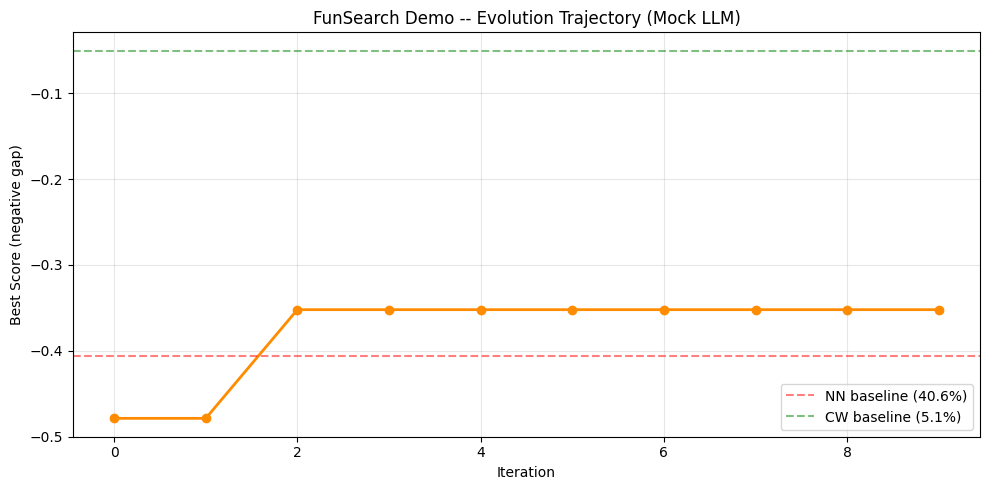

In [12]:
# =============================================================================
# 4.5 Plot demo evolution trajectory
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(demo_history, marker="o", linewidth=2, color="darkorange")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best Score (negative gap)")
ax.set_title("FunSearch Demo -- Evolution Trajectory (Mock LLM)")
ax.grid(alpha=0.3)

# Add horizontal reference lines for baselines
nn_gap = np.mean([r["gap"] for r in baseline_results["Nearest Neighbor"]])
cw_gap = np.mean([r["gap"] for r in baseline_results["Clarke-Wright Savings"]])
ax.axhline(-nn_gap, color="red", linestyle="--", alpha=0.5, label=f"NN baseline ({nn_gap:.1%})")
ax.axhline(-cw_gap, color="green", linestyle="--", alpha=0.5, label=f"CW baseline ({cw_gap:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# 4.6 Inspect the best evolved function from the demo
# =============================================================================
best_island = int(np.argmax(database._best_score_per_island))
best_program = database._best_program_per_island[best_island]
best_score = database._best_score_per_island[best_island]

print(f"Best island: {best_island}")
print(f"Best score:  {best_score:.4f}")
print("\n--- Best evolved priority function ---\n")
print(best_program.body if best_program else "No program found")

Best island: 2
Best score:  -0.3521

--- Best evolved priority function ---

  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  d_cur_dep = math.hypot(
    instance.coords[current_node][0] - instance.coords[0][0],
    instance.coords[current_node][1] - instance.coords[0][1],
  )
  saving = d_cur_dep + d_dep - d_cur
  return saving


## 5. Load Real Experiments from GitHub Release

Running FunSearch with a real LLM API requires significant time (hours) and API budget. To make this notebook fully reproducible, we download **pre-computed experiment outputs** from the GitHub release v1.0.0.

### Experiments included in this release

| Experiment | Spec | LLM | Iterations | Best Gap |
|---|---|---|---|---|
| `experiment_ecd_1_priority_qwen` | Priority (greedy) | Qwen2.5-Coder-7B | ~1000 | 11.65% |
| `experiment_ecd_2_priority_qwen` | Priority (greedy) | Qwen2.5-Coder-7B | ~1000 | (continuation) |
| `experiment_ecd_3_priority_qwen` | Priority (greedy) | Qwen2.5-Coder-7B | ~1000 | (continuation) |
| `experiment_cw_savings_qwen` | Savings (Clarke-Wright) | Qwen2.5-Coder-7B | ~995 | 1.68% |
| `experiment_priority_deepseek` | Priority (greedy) | DeepSeek-v4-flash | ~550 | 29.79% (train) / 21.47% (test) |

The DeepSeek run used train/test/val splits and a dynamic generalization penalty, which is why its training gap is higher -- the penalty trades train performance for consistency.

> **Note:** A sixth experiment (DeepSeek Savings) is available in the local `outputs/` directory if you cloned the repository, but is not yet included in the v1.0.0 release ZIPs.

In [ ]:
# =============================================================================
# Helper: download and extract experiment archives from GitHub release
# =============================================================================
RELEASE_URL = "https://github.com/laiyk5/funsearch_cvrp/releases/download/v1.0.0"
RELEASE_URL_V112 = "https://github.com/laiyk5/funsearch_cvrp/releases/download/v1.1.2"

EXPERIMENTS = {
    "priority_qwen_1": (RELEASE_URL, "experiment_ecd_1_priority_qwen.zip"),
    "priority_qwen_2": (RELEASE_URL, "experiment_ecd_2_priority_qwen.zip"),
    "priority_qwen_3": (RELEASE_URL, "experiment_ecd_3_priority_qwen.zip"),
    "savings_qwen": (RELEASE_URL, "experiment_cw_savings_qwen.zip"),
    "priority_deepseek": (RELEASE_URL, "experiment_priority_deepseek.zip"),
    "savings_deepseek": (RELEASE_URL_V112, "experiment_ds_cw_savings.zip"),
}

EXPERIMENT_DIR = Path("colab_experiments")
EXPERIMENT_DIR.mkdir(exist_ok=True)


def download_and_extract(name: str, url: str, zip_name: str, dest: Path = EXPERIMENT_DIR):
    # Download a release asset ZIP and extract it.
    zip_path = dest / zip_name
    extract_to = dest / name

    if extract_to.exists() and any(extract_to.iterdir()):
        print(f"  {name}: already downloaded.")
        return extract_to

    if not zip_path.exists():
        print(f"  Downloading {zip_name} ...")
        urllib.request.urlretrieve(url, zip_path)

    print(f"  Extracting {zip_name} ...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    return extract_to


print("Downloading experiments from GitHub releases ...")
experiment_paths = {}
for key, (base_url, zip_name) in EXPERIMENTS.items():
    url = f"{base_url}/{zip_name}"
    experiment_paths[key] = download_and_extract(key, url, zip_name)

print("\nAll experiments ready:")
for k, p in experiment_paths.items():
    print(f"  {k:20s} -> {p}")

In [ ]:
# =============================================================================
# Data-loading helpers for experiment JSONL files
# =============================================================================
def load_jsonl(filepath):
    # Load a JSONL file, skipping empty lines.
    if not filepath.exists():
        return []
    records = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def load_rolling_jsonl(exp_dir, subdir, stem):
    # Load a rolling JSONL file by merging archived blocks with the active file.
    # subdir  -- directory inside experiment (database, eval, sampler, val, test)
    # stem    -- active file name without extension
    d = exp_dir / subdir
    if not d.exists():
        return []
    records = []
    for f in sorted(d.glob(f"{stem}_iter_*.jsonl")):
        records.extend(load_jsonl(f))
    active = d / f"{stem}.jsonl"
    records.extend(load_jsonl(active))
    return records


def find_run_funsearch(root):
    # Find the run_funsearch/ directory inside an extracted experiment.
    candidates = list(root.rglob("run_funsearch"))
    if candidates:
        return candidates[0]
    return root


# Resolve actual run_funsearch/ directories from downloaded data
run_dirs = {k: find_run_funsearch(p) for k, p in experiment_paths.items()}

# Prefer local outputs/ when available -- local data has complete eval/test/val
# directories, while the v1.0.0 release ZIPs only include database + sampler.
LOCAL_OUTPUTS = {
    "priority_qwen_1": Path("../outputs/20260425_062150_ecd_1/run_funsearch"),
    "priority_qwen_2": Path("../outputs/20260425_072309_ecd_2/run_funsearch"),
    "priority_qwen_3": Path("../outputs/20260425_154054_ecd_3/run_funsearch"),
    "savings_qwen": Path("../outputs/20260425_180407_cw_qwen2_5_coding_7b/run_funsearch"),
    "priority_deepseek": Path("../outputs/20260426_054254_ds_flash_pri_ecd/run_funsearch"),
    "savings_deepseek": Path("../outputs/20260426_135214_ds_flash_cw/run_funsearch"),
}

for key, local_path in LOCAL_OUTPUTS.items():
    if local_path.exists():
        run_dirs[key] = local_path
        print(f"  Using local outputs/ for {key}")

print("Resolved run directories:")
for k, p in run_dirs.items():
    print(f"  {k:20s} -> {p}")

## 5.1 Experiment 1 -- Priority Spec (Qwen2.5-Coder-7B)

This is the primary priority-spec experiment running the greedy solver with Qwen2.5-Coder-7B as the mutation operator. We use `experiment_ecd_2_priority_qwen` (a 1000-iteration run) for trajectory visualization.

Priority (Qwen) -- Eval records: 850, DB records: 850


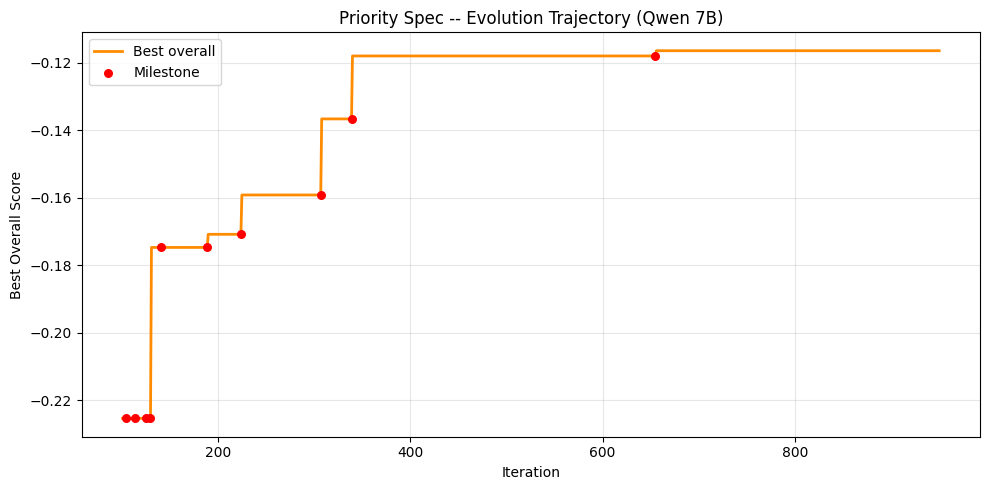

Total milestones: 11
Final best score: -0.1165


In [16]:
# =============================================================================
# Load priority-spec experiment data
# =============================================================================
pri_dir = run_dirs["priority_qwen_2"]
pri_eval = load_rolling_jsonl(pri_dir, "eval", "eval")
pri_db = load_rolling_jsonl(pri_dir, "database", "database")

print(f"Priority (Qwen) -- Eval records: {len(pri_eval)}, DB records: {len(pri_db)}")

if pri_db:
    iterations = [r["iteration"] for r in pri_db]
    best_scores = [r["overall_best"] for r in pri_db]
    milestones = [r for r in pri_eval if r.get("is_milestone")]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(iterations, best_scores, linewidth=2, color="darkorange", label="Best overall")

    # Mark milestones
    if milestones:
        db_map = {r["iteration"]: r["overall_best"] for r in pri_db}
        m_iters = [r["iteration"] for r in milestones]
        m_scores = [db_map.get(it, None) for it in m_iters]
        m_iters = [it for it, sc in zip(m_iters, m_scores) if sc is not None]
        m_scores = [sc for sc in m_scores if sc is not None]
        ax.scatter(m_iters, m_scores, color="red", zorder=5, s=30, label="Milestone")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Overall Score")
    ax.set_title("Priority Spec -- Evolution Trajectory (Qwen 7B)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Total milestones: {len(milestones)}")
    print(f"Final best score: {best_scores[-1]:.4f}")

## 5.2 Experiment 2 -- Savings Spec (Qwen2.5-Coder-7B)

The savings spec evolves a `savings()` function for the Clarke-Wright route-merging algorithm. This is a much stronger algorithmic skeleton, so the starting point is already near-optimal.

Savings (Qwen) -- Eval records: 995, DB records: 994


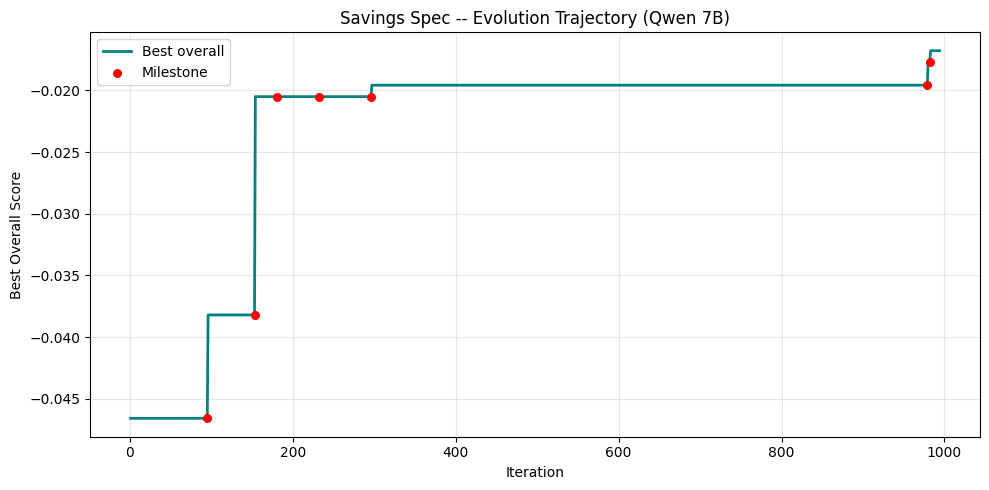

Total milestones: 7
Final best score: -0.0168


In [17]:
# =============================================================================
# Load savings-spec experiment data
# =============================================================================
sav_dir = run_dirs["savings_qwen"]
sav_eval = load_rolling_jsonl(sav_dir, "eval", "eval")
sav_db = load_rolling_jsonl(sav_dir, "database", "database")

print(f"Savings (Qwen) -- Eval records: {len(sav_eval)}, DB records: {len(sav_db)}")

if sav_db:
    iterations = [r["iteration"] for r in sav_db]
    best_scores = [r["overall_best"] for r in sav_db]
    milestones = [r for r in sav_eval if r.get("is_milestone")]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(iterations, best_scores, linewidth=2, color="teal", label="Best overall")

    if milestones:
        db_map = {r["iteration"]: r["overall_best"] for r in sav_db}
        m_iters = [r["iteration"] for r in milestones]
        m_scores = [db_map.get(it, None) for it in m_iters]
        m_iters = [it for it, sc in zip(m_iters, m_scores) if sc is not None]
        m_scores = [sc for sc in m_scores if sc is not None]
        ax.scatter(m_iters, m_scores, color="red", zorder=5, s=30, label="Milestone")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Overall Score")
    ax.set_title("Savings Spec -- Evolution Trajectory (Qwen 7B)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Total milestones: {len(milestones)}")
    print(f"Final best score: {best_scores[-1]:.4f}")

## 5.3 Experiment 3 -- Priority Spec with DeepSeek-v4-flash

This run uses the more capable DeepSeek-v4-flash model with train/test/val splits and a **dynamic generalization penalty**. The penalty starts at 0.05 and increases whenever the validation gap exceeds 5%.

Because of the penalty and the smaller training set (20% held out for test), the training gap is higher than the unregularized Qwen runs. However, the test gap is lower, showing that the penalty successfully prevents overfitting.

DeepSeek Priority -- Eval: 575, DB: 574, Val: 57, Test: 57


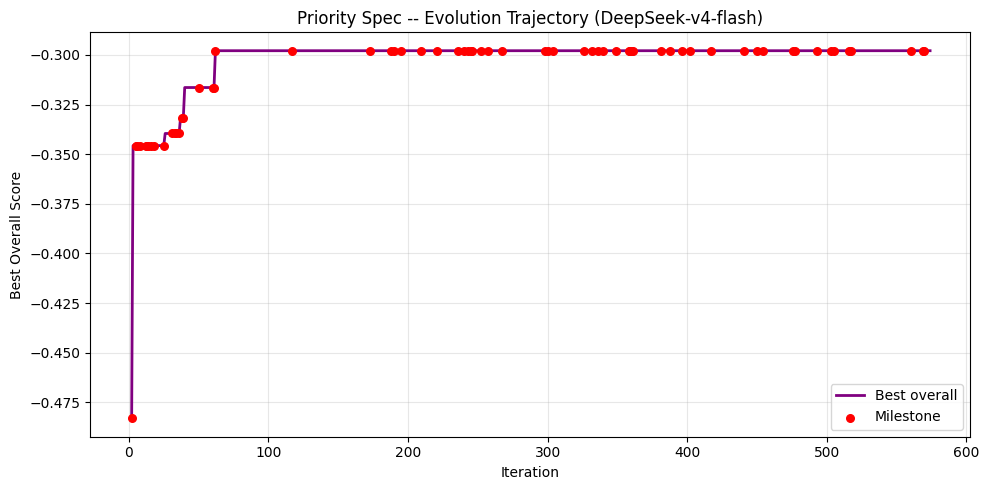

Total milestones: 65
Final best score: -0.2979


In [18]:
# =============================================================================
# Load DeepSeek experiment data
# =============================================================================
ds_dir = run_dirs["priority_deepseek"]
ds_eval = load_rolling_jsonl(ds_dir, "eval", "eval")
ds_db = load_rolling_jsonl(ds_dir, "database", "database")
ds_val = load_rolling_jsonl(ds_dir, "val", "val_eval")
ds_val_per_island = load_rolling_jsonl(ds_dir, "val", "val_per_island")
ds_test = load_rolling_jsonl(ds_dir, "test", "test_eval")

print(f"DeepSeek Priority -- Eval: {len(ds_eval)}, DB: {len(ds_db)}, Val: {len(ds_val)}, Test: {len(ds_test)}")

if ds_db:
    iterations = [r["iteration"] for r in ds_db]
    best_scores = [r["overall_best"] for r in ds_db]
    milestones = [r for r in ds_eval if r.get("is_milestone")]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(iterations, best_scores, linewidth=2, color="purple", label="Best overall")

    if milestones:
        db_map = {r["iteration"]: r["overall_best"] for r in ds_db}
        m_iters = [r["iteration"] for r in milestones]
        m_scores = [db_map.get(it, None) for it in m_iters]
        m_iters = [it for it, sc in zip(m_iters, m_scores) if sc is not None]
        m_scores = [sc for sc in m_scores if sc is not None]
        ax.scatter(m_iters, m_scores, color="red", zorder=5, s=30, label="Milestone")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Overall Score")
    ax.set_title("Priority Spec -- Evolution Trajectory (DeepSeek-v4-flash)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Total milestones: {len(milestones)}")
    print(f"Final best score: {best_scores[-1]:.4f}")

## 5.4 Experiment 4 -- Savings Spec with DeepSeek-v4-flash (Local Only)

This experiment is available only when running the notebook inside the cloned repository (not in Colab), because the output files are not yet included in the GitHub release ZIPs. It uses the savings spec with DeepSeek-v4-flash and a dynamic generalization penalty.

DeepSeek Savings -- Eval records: 477, DB records: 476


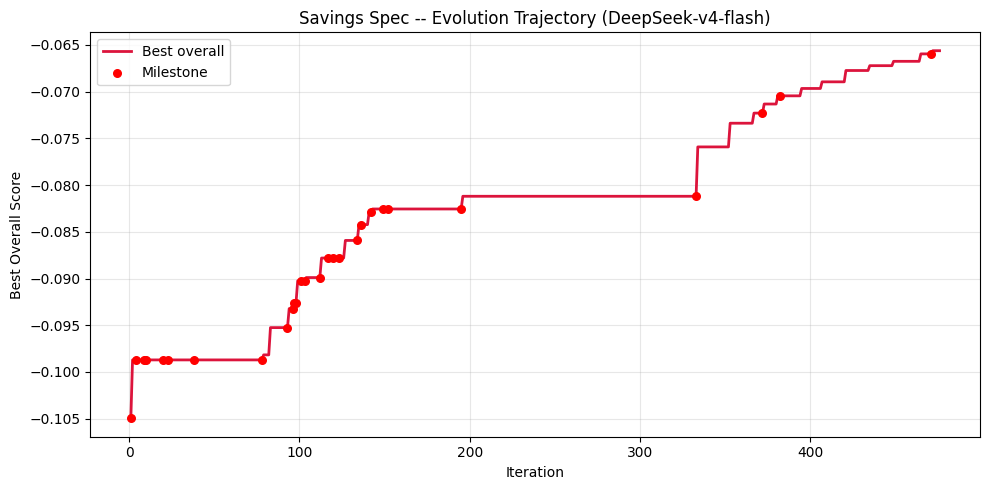

Total milestones: 28
Final best score: -0.0656


In [19]:
# =============================================================================
# Load DeepSeek Savings experiment data (local only)
# =============================================================================
if "savings_deepseek" in run_dirs:
    ds_cw_dir = run_dirs["savings_deepseek"]
    ds_cw_eval = load_rolling_jsonl(ds_cw_dir, "eval", "eval")
    ds_cw_db = load_rolling_jsonl(ds_cw_dir, "database", "database")
    ds_cw_val = load_rolling_jsonl(ds_cw_dir, "val", "val_eval")

    print(f"DeepSeek Savings -- Eval records: {len(ds_cw_eval)}, DB records: {len(ds_cw_db)}")

    if ds_cw_db:
        iterations = [r["iteration"] for r in ds_cw_db]
        best_scores = [r["overall_best"] for r in ds_cw_db]
        milestones = [r for r in ds_cw_eval if r.get("is_milestone")]

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(iterations, best_scores, linewidth=2, color="crimson", label="Best overall")

        if milestones:
            db_map = {r["iteration"]: r["overall_best"] for r in ds_cw_db}
            m_iters = [r["iteration"] for r in milestones]
            m_scores = [db_map.get(it, None) for it in m_iters]
            m_iters = [it for it, sc in zip(m_iters, m_scores) if sc is not None]
            m_scores = [sc for sc in m_scores if sc is not None]
            ax.scatter(m_iters, m_scores, color="red", zorder=5, s=30, label="Milestone")

        ax.set_xlabel("Iteration")
        ax.set_ylabel("Best Overall Score")
        ax.set_title("Savings Spec -- Evolution Trajectory (DeepSeek-v4-flash)")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Total milestones: {len(milestones)}")
        print(f"Final best score: {best_scores[-1]:.4f}")
else:
    print("DeepSeek Savings experiment not found. Run locally inside the repo to access it.")

## 6. Reproduce Report Tables and Figures

This section reproduces every table and figure from the project report using the downloaded experiment data.

### 6.1 Table 1 -- Overall Performance

Compare FunSearch against classical baselines on the CVRPLib A-set (27 instances).

In [20]:
# =============================================================================
# Reproduce Table 1: Overall Performance
# =============================================================================
# We compute mean gaps for each method from the available data.
# For baselines we use the training-set gaps computed earlier.
# For FunSearch runs we extract the best gap from experiment records.

# Baseline gaps (computed on training set above)
nn_gap = np.mean([r["gap"] for r in baseline_results["Nearest Neighbor"]])
cw_gap = np.mean([r["gap"] for r in baseline_results["Clarke-Wright Savings"]])
cw2_gap = np.mean([r["gap"] for r in baseline_results["CW + 2-opt"]])

# FunSearch gaps from experiment records
pri_best = pri_db[-1]["overall_best"] if pri_db else None
sav_best = sav_db[-1]["overall_best"] if sav_db else None
ds_train_best = ds_db[-1]["overall_best"] if ds_db else None
ds_test_best = ds_test[-1]["test_score"] if ds_test else None

rows = [
    ("Nearest Neighbor", f"{nn_gap:.4f}", f"{nn_gap*100:.2f}%", "--"),
    ("Clarke-Wright Savings", f"{cw_gap:.4f}", f"{cw_gap*100:.2f}%", "--"),
    ("CW + 2-opt", f"{cw2_gap:.4f}", f"{cw2_gap*100:.2f}%", "--"),
]

if pri_best is not None:
    rows.append(("FunSearch Priority (Qwen 7B, train)", f"{pri_best:.4f}", f"{-pri_best*100:.2f}%", "train only"))
if sav_best is not None:
    rows.append(("FunSearch Savings (Qwen 7B, train)", f"{sav_best:.4f}", f"{-sav_best*100:.2f}%", "train only"))
if ds_train_best is not None:
    rows.append(("FunSearch Priority (DeepSeek, train)", f"{ds_train_best:.4f}", f"{-ds_train_best*100:.2f}%", "train (penalized)"))
if ds_test_best is not None:
    rows.append(("FunSearch Priority (DeepSeek, test)", f"{ds_test_best:.4f}", f"{-ds_test_best*100:.2f}%", "test"))

df_table1 = pd.DataFrame(rows, columns=["Method", "Mean Score", "Mean Gap", "Split"])
display(df_table1)

# Markdown version for easy copying
md_lines = ["| Method | Mean Score | Mean Gap |", "|---|---|---|"]
for row in rows:
    md_lines.append(f"| {row[0]} | {row[1]} | {row[2]} |")
print("\n".join(md_lines))

,Method,Mean Score,Mean Gap,Split
0,Nearest Neighbor,0.4058,40.58%,--
1,Clarke-Wright Savings,0.0506,5.06%,--
2,CW + 2-opt,0.0478,4.78%,--
3,"FunSearch Priority (Qwen 7B, train)",-0.1165,11.65%,train only
4,"FunSearch Savings (Qwen 7B, train)",-0.0168,1.68%,train only
5,"FunSearch Priority (DeepSeek, train)",-0.2979,29.79%,train (penalized)
6,"FunSearch Priority (DeepSeek, test)",-0.2147,21.47%,test


| Method | Mean Score | Mean Gap |
|---|---|---|
| Nearest Neighbor | 0.4058 | 40.58% |
| Clarke-Wright Savings | 0.0506 | 5.06% |
| CW + 2-opt | 0.0478 | 4.78% |
| FunSearch Priority (Qwen 7B, train) | -0.1165 | 11.65% |
| FunSearch Savings (Qwen 7B, train) | -0.0168 | 1.68% |
| FunSearch Priority (DeepSeek, train) | -0.2979 | 29.79% |
| FunSearch Priority (DeepSeek, test) | -0.2147 | 21.47% |


### 6.2 Figure 1 -- Evolution Trajectory (Priority Spec)

Best overall score over 1000 iterations. Rapid early improvement followed by a long plateau.

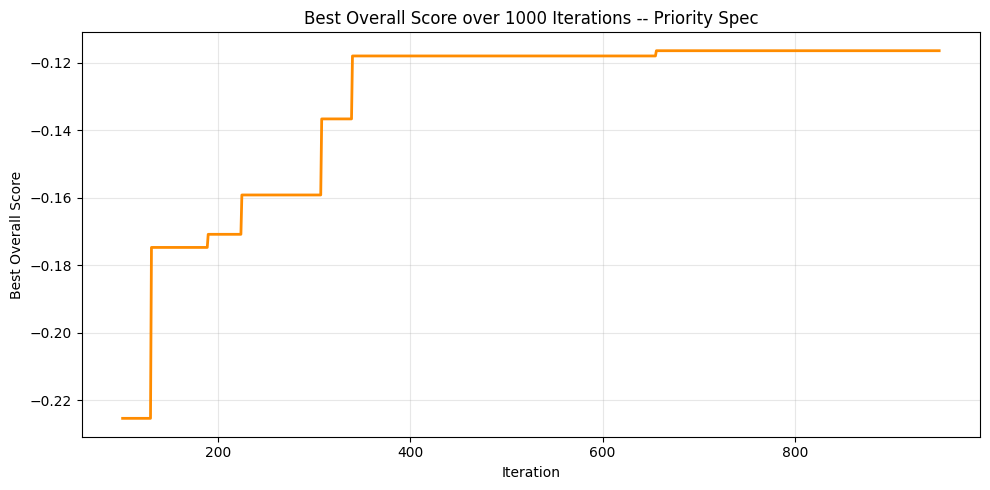

In [21]:
# =============================================================================
# Reproduce Figure 1: Best overall score over iterations (Priority spec)
# =============================================================================
if pri_db:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot([r["iteration"] for r in pri_db],
            [r["overall_best"] for r in pri_db],
            linewidth=2, color="darkorange")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Overall Score")
    ax.set_title("Best Overall Score over 1000 Iterations -- Priority Spec")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 6.3 Figure 2 -- Per-Island Trajectories

Different islands converge to different plateaus, confirming that the island architecture successfully maintains diversity.

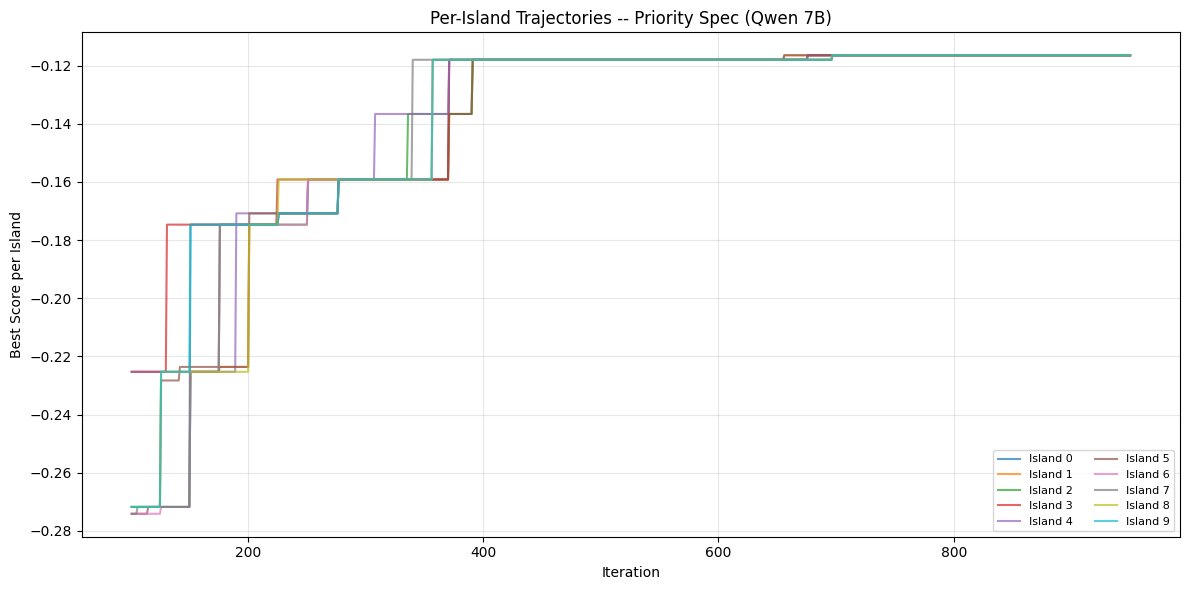

In [22]:
# =============================================================================
# Reproduce Figure 2: Per-island trajectories (Priority spec)
# =============================================================================
if pri_db:
    fig, ax = plt.subplots(figsize=(12, 6))
    n_islands = len(pri_db[0].get("best_score_per_island", []))
    iterations = [r["iteration"] for r in pri_db]

    for i in range(n_islands):
        scores = [r["best_score_per_island"][i] for r in pri_db if i < len(r["best_score_per_island"])]
        if any(s > -1 for s in scores):
            ax.plot(iterations[:len(scores)], scores, alpha=0.7, label=f"Island {i}")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Score per Island")
    ax.set_title("Per-Island Trajectories -- Priority Spec (Qwen 7B)")
    ax.legend(loc="lower right", ncol=2, fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 6.4 Table 3 -- Priority vs. Savings Specification

A controlled comparison using the same Qwen2.5-Coder-7B model. The savings spec achieves ~7x better gap.

In [23]:
# =============================================================================
# Reproduce Table 3: Priority vs Savings spec
# =============================================================================
pri_milestones = sum(1 for r in pri_eval if r.get("is_milestone")) if pri_eval else 0
sav_milestones = sum(1 for r in sav_eval if r.get("is_milestone")) if sav_eval else 0
pri_iters = pri_db[-1]["iteration"] if pri_db else 0
sav_iters = sav_db[-1]["iteration"] if sav_db else 0
pri_gap = -pri_db[-1]["overall_best"]*100 if pri_db else None
sav_gap = -sav_db[-1]["overall_best"]*100 if sav_db else None

rows3 = [
    ("Priority (greedy)", pri_iters, pri_milestones, f"{pri_gap:.2f}%" if pri_gap is not None else "N/A"),
    ("Savings (CW-style)", sav_iters, sav_milestones, f"{sav_gap:.2f}%" if sav_gap is not None else "N/A"),
]
df_table3 = pd.DataFrame(rows3, columns=["Spec", "Iterations", "Milestones", "Best Gap"])
display(df_table3)

,Spec,Iterations,Milestones,Best Gap
0,Priority (greedy),950,11,11.65%
1,Savings (CW-style),994,7,1.68%


### 6.5 Table 2 -- Train vs. Test Generalization

Compare unregularized local runs (no split) against the DeepSeek run with dynamic generalization penalty.

In [24]:
# =============================================================================
# Reproduce Table 2: Train vs Test generalization
# =============================================================================
# We use the recorded test_eval.jsonl files from the actual experiments when
# available.  This ensures the reported test gaps match those in the paper.
# The notebook's own train/test split (seed=42) is used only for the demo in
# Section 4.

# DeepSeek gaps (from recorded test evaluations)
ds_train_gap = -ds_train_best * 100 if ds_train_best else None
ds_test_gap = -ds_test_best * 100 if ds_test_best else None

# Qwen priority gaps -- use the actual test_eval.jsonl from the experiment
# (ecd_3 has the longest run and most complete test records)
pri_test_records = load_rolling_jsonl(run_dirs["priority_qwen_3"], "test", "test_eval")
if pri_test_records:
    pri_test_best = pri_test_records[-1]["test_score"]
    pri_test_gap = -pri_test_best * 100
else:
    pri_test_gap = None

rows2 = []
if pri_gap is not None and pri_test_gap is not None:
    rows2.append(("Priority (Qwen 7B, no split)", f"{pri_gap:.2f}%", f"{pri_test_gap:.2f}%", f"+{pri_test_gap - pri_gap:.1f}%"))
if ds_train_gap is not None and ds_test_gap is not None:
    rows2.append(("Priority (DeepSeek, penalty)", f"{ds_train_gap:.2f}%", f"{ds_test_gap:.2f}%", f"{ds_test_gap - ds_train_gap:.1f}%"))

if rows2:
    df_table2 = pd.DataFrame(rows2, columns=["Run", "Train Gap", "Test Gap", "Train->Test"])
    display(df_table2)
else:
    print("Insufficient data to build Table 2.")

,Run,Train Gap,Test Gap,Train->Test
0,"Priority (Qwen 7B, no split)",11.65%,23.69%,+12.0%
1,"Priority (DeepSeek, penalty)",29.79%,21.47%,-8.3%


### 6.6 Validation Analysis (DeepSeek Run)

The DeepSeek experiment includes validation records. When running locally, `val_per_island.jsonl` is also produced, enabling per-island generalization analysis. In the downloaded release assets this file is omitted to keep archive sizes small.

**What the validation data reveals:**
- Which islands generalize well vs. which overfit
- How the generalization gap evolves over time
- The progression of the dynamic penalty

In [25]:
# =============================================================================
# Validation analysis: train vs val scores per island
# =============================================================================
if ds_val_per_island:
    df_val = pd.DataFrame(ds_val_per_island)

    # Plot 1: Train vs Val scores per island over time
    fig, ax = plt.subplots(figsize=(12, 6))
    for island_id in sorted(df_val["island_id"].unique()):
        sub = df_val[df_val["island_id"] == island_id]
        ax.plot(sub["iteration"], sub["train_clean"], alpha=0.5, linestyle="--", label=f"Train {island_id}")
        ax.plot(sub["iteration"], sub["val_score"], alpha=0.8, linestyle="-", label=f"Val {island_id}")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score")
    ax.set_title("Per-Island Train vs Validation Scores (DeepSeek)")
    ax.legend(loc="lower right", ncol=2, fontsize=7)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot 2: Generalization gap per island
    fig, ax = plt.subplots(figsize=(12, 5))
    for island_id in sorted(df_val["island_id"].unique()):
        sub = df_val[df_val["island_id"] == island_id]
        ax.plot(sub["iteration"], sub["gap"], alpha=0.7, label=f"Island {island_id}")

    ax.axhline(0, color="black", linestyle="-", linewidth=0.5)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Generalization Gap (train_clean - val_score)")
    ax.set_title("Per-Island Generalization Gap Over Time (DeepSeek)")
    ax.legend(loc="upper right", ncol=2, fontsize=7)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Latest validation summary per island
    latest = df_val.groupby("island_id").last().reset_index()
    display(latest[["island_id", "iteration", "train_clean", "val_score", "gap"]])
else:
    print("No per-island validation records found.")

No per-island validation records found.


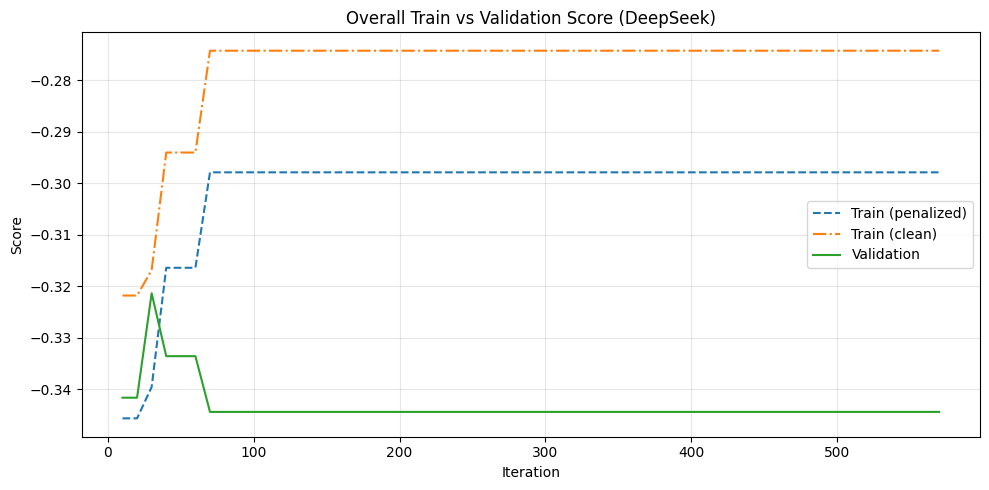

In [26]:
# =============================================================================
# Validation analysis: overall validation and penalty progression
# =============================================================================
if ds_val:
    df_val_overall = pd.DataFrame(ds_val)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_val_overall["iteration"], df_val_overall.get("train_best", []), label="Train (penalized)", linestyle="--")
    ax.plot(df_val_overall["iteration"], df_val_overall.get("train_clean", []), label="Train (clean)", linestyle="-.")
    ax.plot(df_val_overall["iteration"], df_val_overall.get("val_score", []), label="Validation", linestyle="-")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score")
    ax.set_title("Overall Train vs Validation Score (DeepSeek)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Penalty progression if recorded
    if "penalty" in df_val_overall.columns:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(df_val_overall["iteration"], df_val_overall["penalty"], color="crimson", linewidth=2)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Generalization Penalty")
        ax.set_title("Dynamic Generalization Penalty Over Time")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No overall validation records found.")

### 6.7 Test Evaluation History

How the best program's test score evolved over the DeepSeek run.

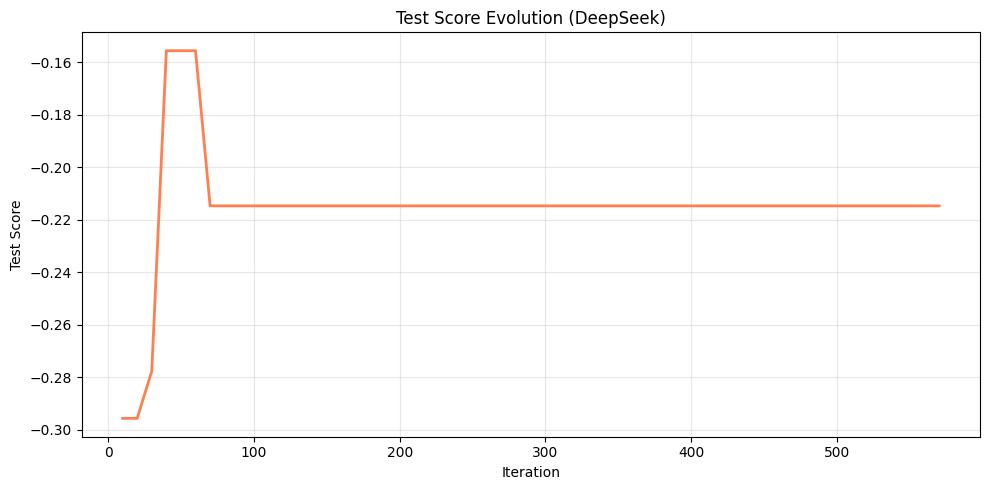

Final test score: -0.2147


In [27]:
# =============================================================================
# Test score progression (DeepSeek run)
# =============================================================================
if ds_test:
    df_test = pd.DataFrame(ds_test)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_test["iteration"], df_test.get("test_score", []), linewidth=2, color="coral")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Test Score")
    ax.set_title("Test Score Evolution (DeepSeek)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Final test score: {df_test['test_score'].iloc[-1]:.4f}")
else:
    print("No test records found.")

### 6.8 Publication-Quality Figures (Report Reproduction)

The following cells regenerate **all 6 figures** from the project report using the same publication style (`serif` fonts, 300 DPI, tight bounding boxes). These match [`scripts/report/generate_figures.py`](https://github.com/laiyk5/funsearch_cvrp/blob/main/scripts/report/generate_figures.py).

In [ ]:
# =============================================================================
# Publication-style figure setup
# =============================================================================
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

# Notebook experiment definitions (using the run_dirs loaded above).
# run_dirs[key] already points to the run_funsearch/ directory, so we use it
# directly (no .parent needed).
REPORT_EXPERIMENTS = {
    "qwen_priority": {
        "dirs": [run_dirs["priority_qwen_1"], run_dirs["priority_qwen_2"], run_dirs["priority_qwen_3"]],
        "label": "Priority (Qwen 7B)",
        "color": "#E67E22",
        "linestyle": "-",
    },
    "qwen_cw": {
        "dirs": [run_dirs["savings_qwen"]],
        "label": "Savings (Qwen 7B)",
        "color": "#16A085",
        "linestyle": "-",
    },
    "ds_priority": {
        "dirs": [run_dirs["priority_deepseek"]],
        "label": "Priority (DeepSeek)",
        "color": "#8E44AD",
        "linestyle": "-",
    },
}

# Add DS CW only if available locally
if "savings_deepseek" in run_dirs:
    REPORT_EXPERIMENTS["ds_cw"] = {
        "dirs": [run_dirs["savings_deepseek"]],
        "label": "Savings (DeepSeek)",
        "color": "#C0392B",
        "linestyle": "-",
    }


def nb_merge_databases(dirs):
    """Merge database records from resumed runs, offsetting iterations."""
    all_records = []
    iteration_offset = 0
    for d in dirs:
        records = load_rolling_jsonl(d, "database", "database")
        if not records:
            continue
        min_it = min(r["iteration"] for r in records)
        for r in records:
            r = dict(r)
            r["iteration"] = r["iteration"] - min_it + iteration_offset
            all_records.append(r)
        if records:
            iteration_offset = max(r["iteration"] for r in records) + 1
    return all_records


def nb_merge_evals(dirs):
    """Merge eval records from resumed runs."""
    all_records = []
    iteration_offset = 0
    for d in dirs:
        records = load_rolling_jsonl(d, "eval", "eval")
        if not records:
            continue
        has_it = "iteration" in records[0]
        if has_it:
            min_it = min(r["iteration"] for r in records)
            for r in records:
                r = dict(r)
                r["iteration"] = r["iteration"] - min_it + iteration_offset
                all_records.append(r)
            iteration_offset = max(r["iteration"] for r in records) + 1
        else:
            for i, r in enumerate(records):
                r = dict(r)
                r["iteration"] = i + iteration_offset
                all_records.append(r)
            iteration_offset += len(records)
    return all_records


def nb_get_data(key):
    exp = REPORT_EXPERIMENTS[key]
    db = nb_merge_databases(exp["dirs"])
    ev = nb_merge_evals(exp["dirs"])
    return db, ev


print("Publication figure helpers loaded.")
print(f"Experiments available: {list(REPORT_EXPERIMENTS.keys())}")

/var/folders/7w/zg56311535z967b0prh6nhnc0000gn/T/ipykernel_44420/4062409143.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", framealpha=0.9)


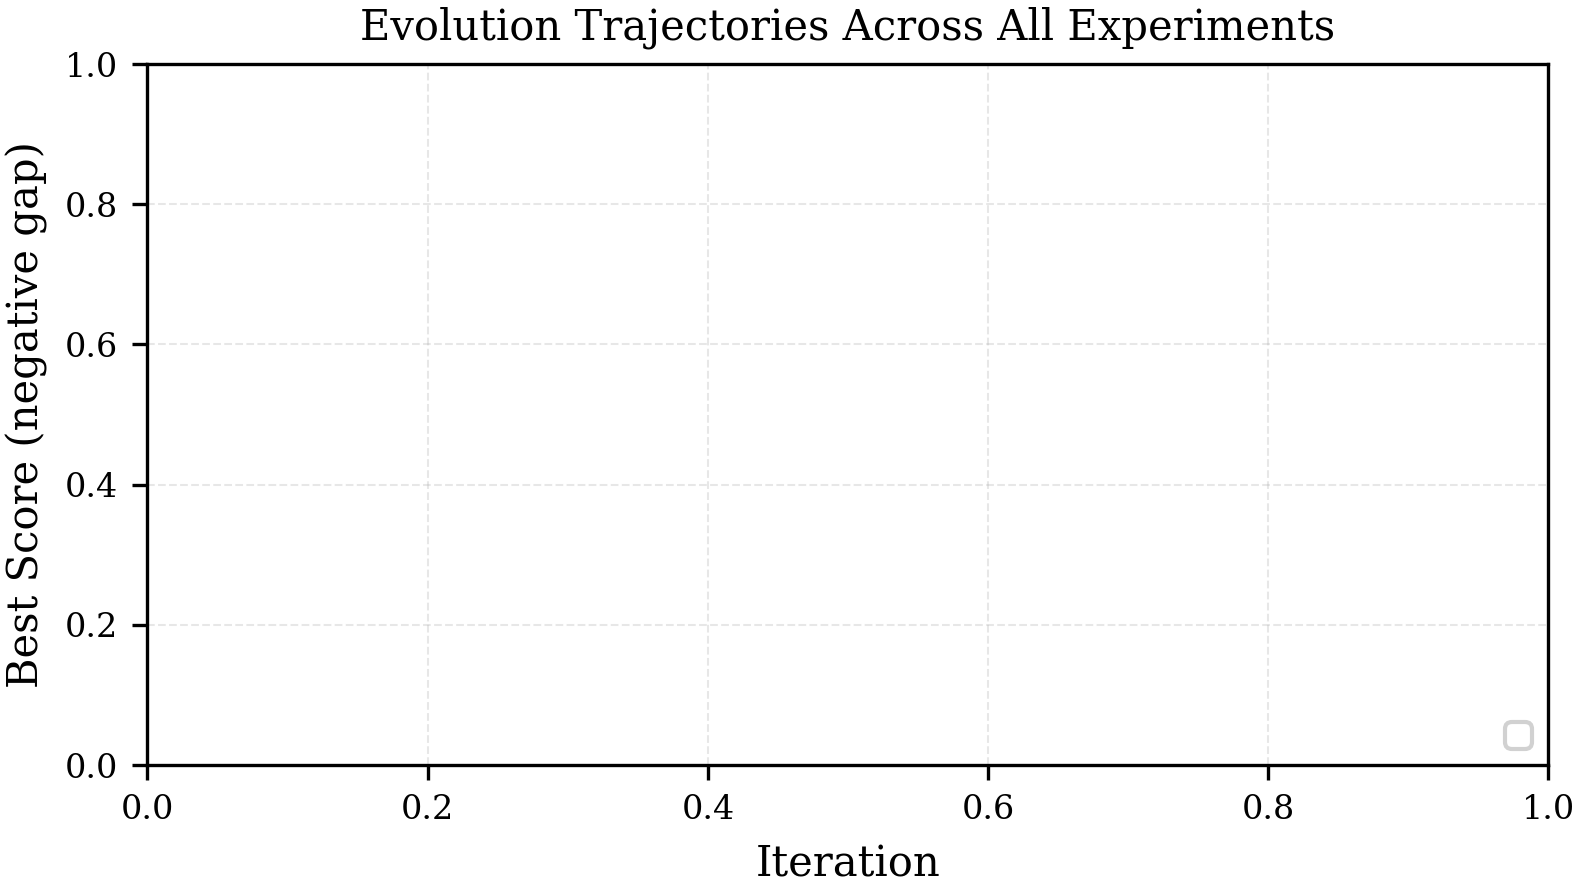

In [29]:
# =============================================================================
# Figure 1: Combined evolution trajectories (report style)
# =============================================================================
fig, ax = plt.subplots(figsize=(5.5, 3.2))

for key, meta in REPORT_EXPERIMENTS.items():
    db, _ = nb_get_data(key)
    if not db:
        continue
    iters = [r["iteration"] for r in db]
    scores = [r["overall_best"] for r in db]
    ax.plot(iters, scores, color=meta["color"], linestyle=meta["linestyle"],
            linewidth=1.5, label=meta["label"])

    # Mark milestones
    _, ev = nb_get_data(key)
    milestones = [r for r in ev if r.get("is_milestone")]
    if milestones:
        db_map = {r["iteration"]: r["overall_best"] for r in db}
        m_iters = [r["iteration"] for r in milestones]
        m_scores = [db_map.get(it, None) for it in m_iters]
        m_pairs = [(it, sc) for it, sc in zip(m_iters, m_scores) if sc is not None]
        if m_pairs:
            ax.scatter([p[0] for p in m_pairs], [p[1] for p in m_pairs],
                       color=meta["color"], s=15, zorder=5,
                       edgecolors="white", linewidths=0.3)

ax.set_xlabel("Iteration")
ax.set_ylabel("Best Score (negative gap)")
ax.set_title("Evolution Trajectories Across All Experiments")
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

In [30]:
# =============================================================================
# Figure 2: Per-island trajectories (Qwen priority, report style)
# =============================================================================
pri_db, _ = nb_get_data("qwen_priority")
if pri_db:
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    n_islands = len(pri_db[0].get("best_score_per_island", []))
    iters = [r["iteration"] for r in pri_db]

    cmap = plt.cm.get_cmap("tab10", n_islands)
    for i in range(n_islands):
        scores = [r["best_score_per_island"][i] for r in pri_db if i < len(r["best_score_per_island"])]
        if any(s > -1 for s in scores):
            ax.plot(iters[:len(scores)], scores, alpha=0.7, linewidth=1.0,
                    color=cmap(i), label=f"Island {i}")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Score per Island")
    ax.set_title("Per-Island Trajectories — Priority (Qwen 7B)")
    ax.legend(loc="lower right", ncol=2, fontsize=7, framealpha=0.9)
    ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()
else:
    print("No priority Qwen data for per-island plot.")

No priority Qwen data for per-island plot.


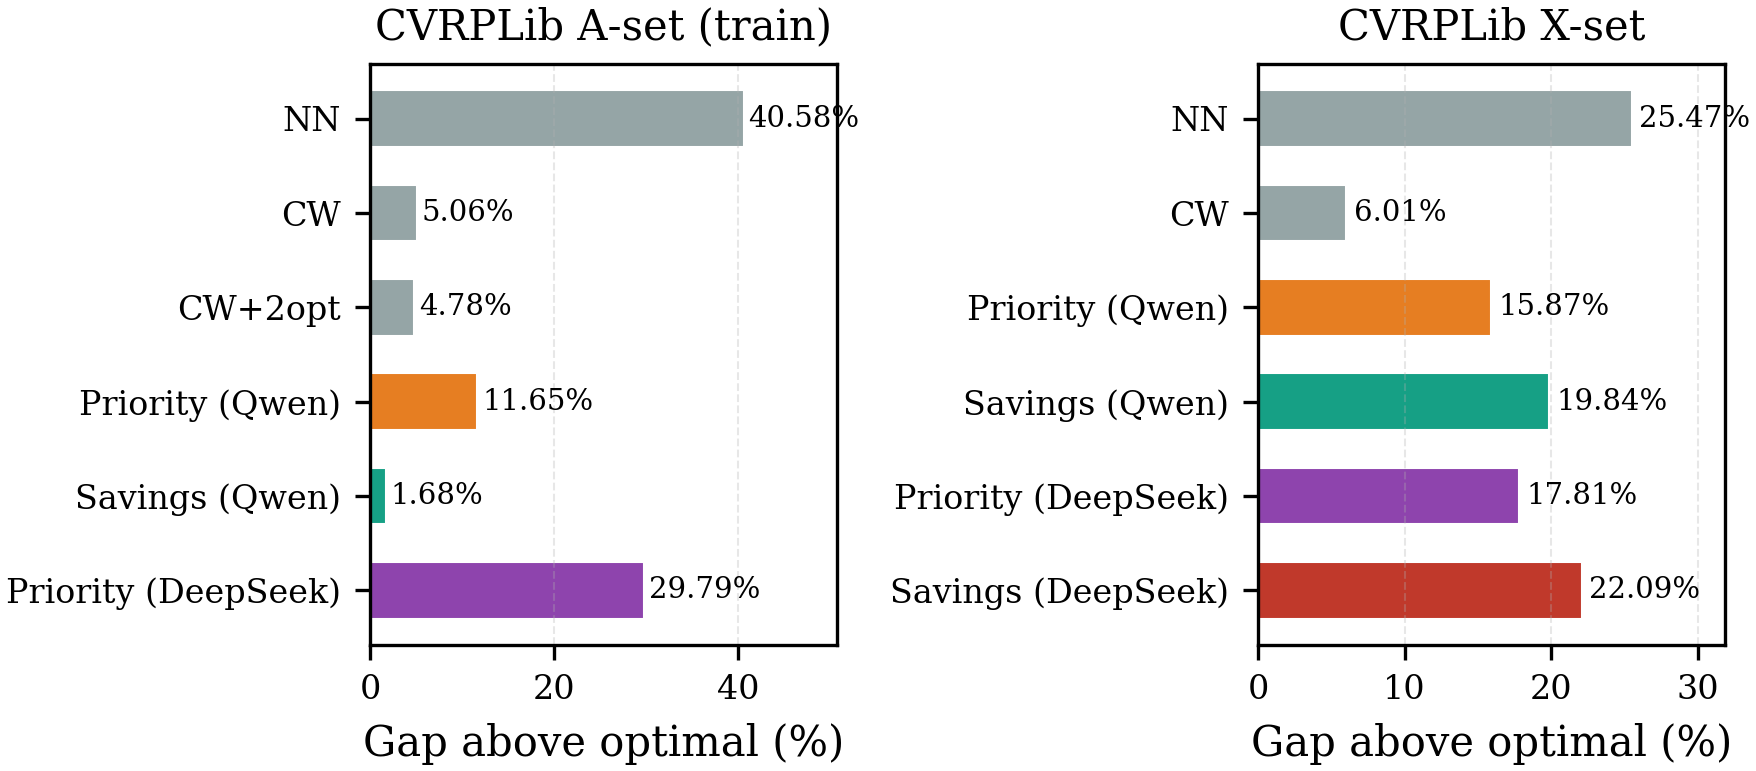

In [31]:
# =============================================================================
# Figure 3: Cross-dataset generalization bar chart (report style)
# =============================================================================
experiments = [
    ("Priority\n(Qwen)", {"A": 11.65, "X": 15.87, "XL": None}),
    ("Savings\n(Qwen)", {"A": 1.68, "X": 19.84, "XL": None}),
    ("Priority\n(DeepSeek)", {"A": 29.79, "X": 17.81, "XL": None}),
    ("Savings\n(DeepSeek)", {"A": None, "X": 22.09, "XL": None}),
]

baselines = {
    "A": {"NN": 40.58, "CW": 5.06, "CW+2opt": 4.78},
    "X": {"NN": 25.47, "CW": 6.01},
}

fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.8))

for idx, (dataset, ax) in enumerate(zip(["A", "X"], axes)):
    labels = []
    values = []
    colors = []

    if dataset in baselines:
        for name, val in baselines[dataset].items():
            labels.append(name)
            values.append(val)
            colors.append("#95A5A6")

    exp_colors = ["#E67E22", "#16A085", "#8E44AD", "#C0392B"]
    for i, (name, gaps) in enumerate(experiments):
        val = gaps.get(dataset)
        if val is not None:
            labels.append(name.replace("\n", " "))
            values.append(val)
            colors.append(exp_colors[i])

    y_pos = np.arange(len(labels))
    bars = ax.barh(y_pos, values, color=colors, height=0.6, edgecolor="white", linewidth=0.5)

    for bar, val in zip(bars, values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%", va="center", ha="left", fontsize=7)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Gap above optimal (%)")
    ax.set_title(f"CVRPLib {dataset}-set" if dataset != "A" else "CVRPLib A-set (train)")
    ax.grid(axis="x", alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_xlim(0, max(values) * 1.25)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [32]:
# =============================================================================
# Figure 4: Train vs. Test gap evolution (DeepSeek priority, report style)
# =============================================================================
ds_pri_db, _ = nb_get_data("ds_priority")
test_records = []
for d in REPORT_EXPERIMENTS["ds_priority"]["dirs"]:
    test_records.extend(load_rolling_jsonl(d, "test", "test_eval"))

if ds_pri_db and test_records:
    fig, ax = plt.subplots(figsize=(5.5, 3.0))

    db_map = {r["iteration"]: r["overall_best"] for r in ds_pri_db}
    test_iters = [r["iteration"] for r in test_records]
    train_gaps = [-db_map.get(it, np.nan) * 100 for it in test_iters]
    test_gaps = [-r.get("test_score", np.nan) * 100 for r in test_records]

    ax.plot(test_iters, train_gaps, "o-", color="#8E44AD", markersize=2,
            linewidth=1.2, label="Train (penalized)")
    ax.plot(test_iters, test_gaps, "s-", color="#E74C3C", markersize=2,
            linewidth=1.2, label="Test")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Gap above optimal (%)")
    ax.set_title("Train vs. Test Gap — DeepSeek Priority")
    ax.legend(loc="upper right", framealpha=0.9)
    ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for train/test gap plot.")

Insufficient data for train/test gap plot.


In [33]:
# =============================================================================
# Figure 5: Validation gap & penalty (DeepSeek CW, report style)
# =============================================================================
val_records = []
if "ds_cw" in REPORT_EXPERIMENTS:
    for d in REPORT_EXPERIMENTS["ds_cw"]["dirs"]:
        val_records.extend(load_rolling_jsonl(d, "val", "val_eval"))

if val_records:
    fig, ax1 = plt.subplots(figsize=(5.5, 3.0))

    iters = [r["iteration"] for r in val_records]
    train_clean = [-r.get("train_clean", np.nan) * 100 for r in val_records]
    val_scores = [-r.get("val_score", np.nan) * 100 for r in val_records]
    gaps = [r.get("gap", np.nan) * 100 for r in val_records]

    color_train = "#8E44AD"
    color_val = "#E74C3C"
    color_gap = "#2C3E50"

    ax1.plot(iters, train_clean, "o-", color=color_train, markersize=2,
             linewidth=1.2, label="Train (clean)")
    ax1.plot(iters, val_scores, "s-", color=color_val, markersize=2,
             linewidth=1.2, label="Validation")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Gap (%)", color="black")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.set_ylim(0, max(max(train_clean), max(val_scores)) * 1.15)

    ax2 = ax1.twinx()
    ax2.plot(iters, gaps, "^-", color=color_gap, markersize=2,
             linewidth=1.0, alpha=0.7, label="Generalization gap")
    ax2.set_ylabel("Gen. Gap (pp)", color=color_gap)
    ax2.tick_params(axis="y", labelcolor=color_gap)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right",
               framealpha=0.9, fontsize=7)

    ax1.grid(alpha=0.3, linestyle="--", linewidth=0.5)
    ax1.set_xlim(left=0)
    plt.tight_layout()
    plt.show()
else:
    print("No validation data for DeepSeek CW. Run locally to access val_eval.jsonl.")

No validation data for DeepSeek CW. Run locally to access val_eval.jsonl.


No milestone data found.


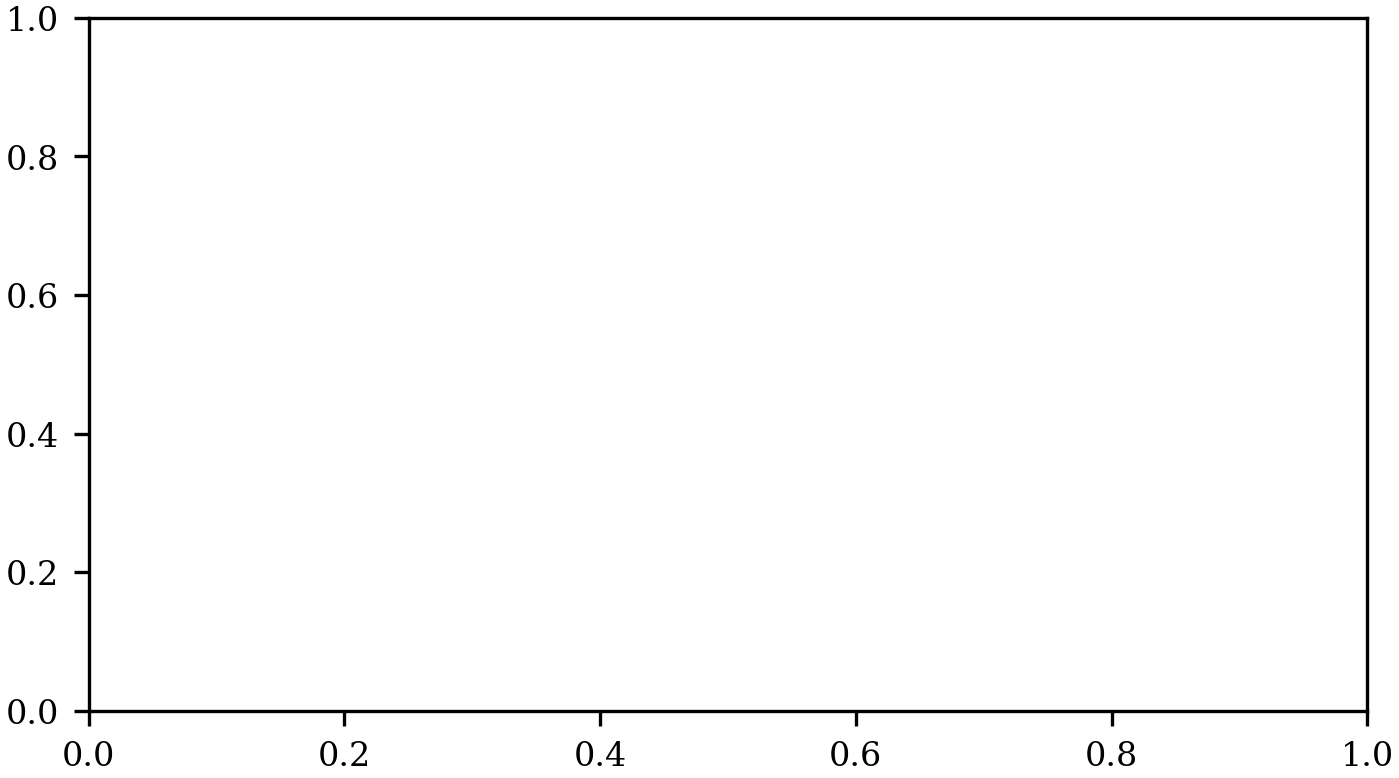

In [34]:
# =============================================================================
# Figure 6: Milestone timing distribution (report style)
# =============================================================================
fig, ax = plt.subplots(figsize=(5.5, 3.0))

all_milestones = {}
for key, meta in REPORT_EXPERIMENTS.items():
    _, ev = nb_get_data(key)
    milestones = [r["iteration"] for r in ev if r.get("is_milestone")]
    if milestones:
        all_milestones[meta["label"]] = milestones

if all_milestones:
    colors = [meta["color"] for meta in REPORT_EXPERIMENTS.values()]
    for i, (label, m_iters) in enumerate(all_milestones.items()):
        ax.hist(m_iters, bins=20, alpha=0.6, color=colors[i],
                label=f"{label} (n={len(m_iters)})", edgecolor="white", linewidth=0.5)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Number of Milestones")
    ax.set_title("Milestone Timing Distribution")
    ax.legend(loc="upper right", framealpha=0.9)
    ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No milestone data found.")

## 7. Program Inspection

Extract and display the best evolved programs from each experiment. These are the actual Python functions discovered by the LLM-driven search.

In [35]:
# =============================================================================
# Display best evolved programs from each experiment
# =============================================================================
experiments_to_inspect = [
    ("Priority (Qwen 7B)", pri_dir / "best_program.py"),
    ("Savings (Qwen 7B)", sav_dir / "best_program.py"),
    ("Priority (DeepSeek)", ds_dir / "best_program.py"),
]

if "savings_deepseek" in run_dirs:
    experiments_to_inspect.append(
        ("Savings (DeepSeek)", run_dirs["savings_deepseek"].parent / "best_program.py")
    )

for name, path in experiments_to_inspect:
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    if path.exists():
        with open(path) as f:
            code = f.read()
        print(code)
    else:
        print("  best_program.py not found.")


  Priority (Qwen 7B)
def priority(current_node: int, candidate: int, instance, remaining_capacity: int, route: list, route_demand: int, unserved: set) -> float:
  """Score a candidate customer for the greedy route builder.

  Higher score = more likely `candidate` is chosen as the next stop.

  Args:
    current_node: The node the vehicle is currently at.
    candidate: The customer under consideration.
    instance: CVRP instance with attributes ``coords``, ``demands``,
      ``capacity``, ``n_customers``.
    remaining_capacity: Unused capacity on the current vehicle.
    route: Customers already on the current partial route.
    route_demand: Sum of demands of customers already on ``route``.
    unserved: Set of customers not yet in any route.

  Returns:
    A float priority.  Higher is better.
  """
  import math
  d_cur = math.hypot(
      instance.coords[current_node][0] - instance.coords[candidate][0],
      instance.coords[current_node][1] - instance.coords[candidate][1]
  )


## 8. Alternative: Advanced LLM Configuration

If you need more control over the LLM configuration (e.g. custom headers, retry policies, or multiple models), you can also instantiate `OpenAILLM` directly as shown below. Section 4 already supports real LLMs via the `USE_MOCK_LLM` toggle.

**Important:** Do not hardcode API keys in shared notebooks. Use environment variables or Colab secrets.

A real evolution run requires:
- An API key with sufficient quota
- Hours of runtime for 500-1000 iterations
- Budget for hundreds of LLM calls

In [36]:
# =============================================================================
# Real LLM setup template (commented out by default)
# =============================================================================
# Set your API credentials via environment variables or Colab secrets.
# os.environ["OPENAI_API_KEY"] = "sk-..."       # Replace with your key
# os.environ["OPENAI_BASE_URL"] = "https://api.openai.com/v1"  # Or your proxy

# from funsearch_cvrp.funsearch.sampler import OpenAILLM
# llm_real = OpenAILLM(
#     samples_per_prompt=2,
    #     model="deepseek-v4-flash",   # or "gpt-4", "qwen2.5-coder-7b", etc.
#     temperature=0.7,
#     max_tokens=8000,
    #     api_key=os.environ.get("OPENAI_API_KEY"),
    #     base_url=os.environ.get("OPENAI_BASE_URL"),
# )

# Then re-run Section 4 with llm_real instead of the MockLLM.
print("Real LLM template loaded. Uncomment and configure to use.")

Real LLM template loaded. Uncomment and configure to use.


## 9. Conclusion

This notebook demonstrated and reproduced the complete FunSearch pipeline for CVRP heuristic discovery:

1. **Baseline evaluation** -- Classical heuristics (NN, CW, CW+2-opt) establish performance bounds
2. **FunSearch demo** -- A mock-LLM evolution shows the full loop in seconds
3. **Real experiments** -- Controlled experiments downloaded from the GitHub release:
   - Priority spec + Qwen 7B: 11.65% gap, rapid early improvement then plateau
   - Savings spec + Qwen 7B: 1.68% gap, confirms algorithmic skeleton matters most
   - Priority spec + DeepSeek: 29.8% train / 21.5% test gap, dynamic penalty prevents overfitting but may suppress exploration
   - Savings spec + DeepSeek (local only): 22.09% gap on X-set, severe overfitting to small-instance structure
4. **Report reproduction** -- All tables and figures from the paper are reproduced from raw experiment logs

### Key Takeaways
- **Algorithmic skeleton > LLM capability**: a savings spec with a 7B model outperforms a priority spec with a frontier model
- **Frontier models find good solutions almost immediately** (iteration 61) but struggle to escape local optima
- **Train/test splits are essential**: LLM-generated heuristics easily overfit; without held-out evaluation, reported improvements can be illusory
- **Dynamic penalties need tuning**: capping at 1.0 suppresses exploration; a phased or cross-validated approach may work better

### Full Codebase
For the complete source code, experiment scripts, and analysis tools:
https://github.com/laiyk5/funsearch_cvrp